In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import joblib

In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

for file in (PROJECT_ROOT / "outputs").glob("*.pkl"):
    print(file.name)

advanced_scaler.pkl
label_encoder.pkl
natural_sound_classifier.pkl
rf_advanced_model.pkl


In [4]:
PROJECT_ROOT = Path.cwd().parent

model = joblib.load(
    PROJECT_ROOT /
    "outputs" /
    "rf_advanced_model.pkl"
)

print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [5]:
scaler = joblib.load(
    PROJECT_ROOT /
    "outputs" /
    "advanced_scaler.pkl"
)

encoder = joblib.load(
    PROJECT_ROOT /
    "outputs" /
    "label_encoder.pkl"
)

print("Model Loaded")
print("Scaler Loaded")
print("Encoder Loaded")

Model Loaded
Scaler Loaded
Encoder Loaded


In [6]:
advanced_df = pd.read_csv(
    PROJECT_ROOT /
    "outputs" /
    "advanced_audio_features.csv"
)

print(advanced_df.shape)
advanced_df.head()

(520, 40)


,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,...,contrast_6,contrast_7,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5,tonnetz_6,filename,category
0,-254.93631,85.83962,-107.103160,31.011576,-39.987736,-17.290342,-37.214104,-18.145690,-11.705071,-17.621454,...,20.464414,45.704715,-0.058836,0.004075,0.051868,0.035464,-0.014806,-0.015532,1-100038-A-14.wav,chirping_birds
1,-466.62210,144.26140,22.961350,52.213543,2.970680,11.319603,-2.895933,0.076406,-8.929120,10.019115,...,16.233288,28.473721,0.002136,-0.003342,-0.027320,0.071995,-0.018120,0.001736,1-101296-A-19.wav,thunderstorm
2,-441.77423,153.39592,32.532093,38.864770,0.386356,-1.514098,2.681722,-3.470331,-3.546912,5.873673,...,16.746074,28.574655,-0.005311,0.008006,-0.021965,0.031961,0.004954,0.005678,1-101296-B-19.wav,thunderstorm
3,-173.18240,131.66370,-23.350657,44.626896,-16.704086,34.943077,13.708267,24.017622,-3.575602,12.136042,...,15.456582,42.903741,0.002883,0.021413,-0.012975,-0.041927,0.009535,0.009389,1-103298-A-9.wav,crow
4,-400.28085,155.72517,73.404076,15.198190,5.499929,16.989422,18.179058,7.343544,-0.929693,-1.168286,...,15.181650,16.613661,0.004814,0.000623,-0.009786,0.010140,0.004016,0.000385,1-115521-A-19.wav,thunderstorm


In [7]:
feature_columns = [
    col
    for col in advanced_df.columns
    if col not in ["filename", "category"]
]

print(len(feature_columns))

38


In [8]:
importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
1,mfcc_2,0.066096
2,mfcc_3,0.053163
0,mfcc_1,0.048276
27,contrast_3,0.043714
29,contrast_5,0.042531
31,contrast_7,0.041617
30,contrast_6,0.040096
3,mfcc_4,0.036579
28,contrast_4,0.033881
4,mfcc_5,0.029789


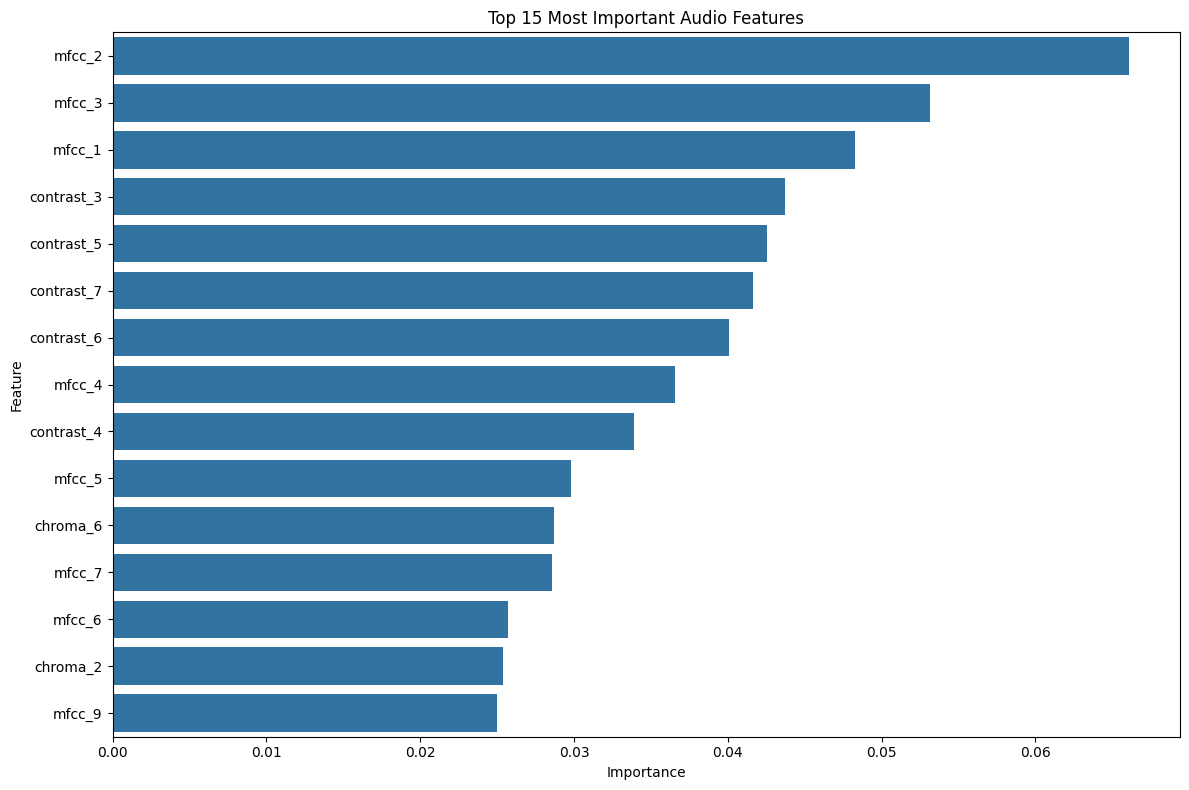

In [9]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Most Important Audio Features"
)

plt.tight_layout()

plt.show()

In [10]:
importance_df.head(10)

,Feature,Importance
1,mfcc_2,0.066096
2,mfcc_3,0.053163
0,mfcc_1,0.048276
27,contrast_3,0.043714
29,contrast_5,0.042531
31,contrast_7,0.041617
30,contrast_6,0.040096
3,mfcc_4,0.036579
28,contrast_4,0.033881
4,mfcc_5,0.029789


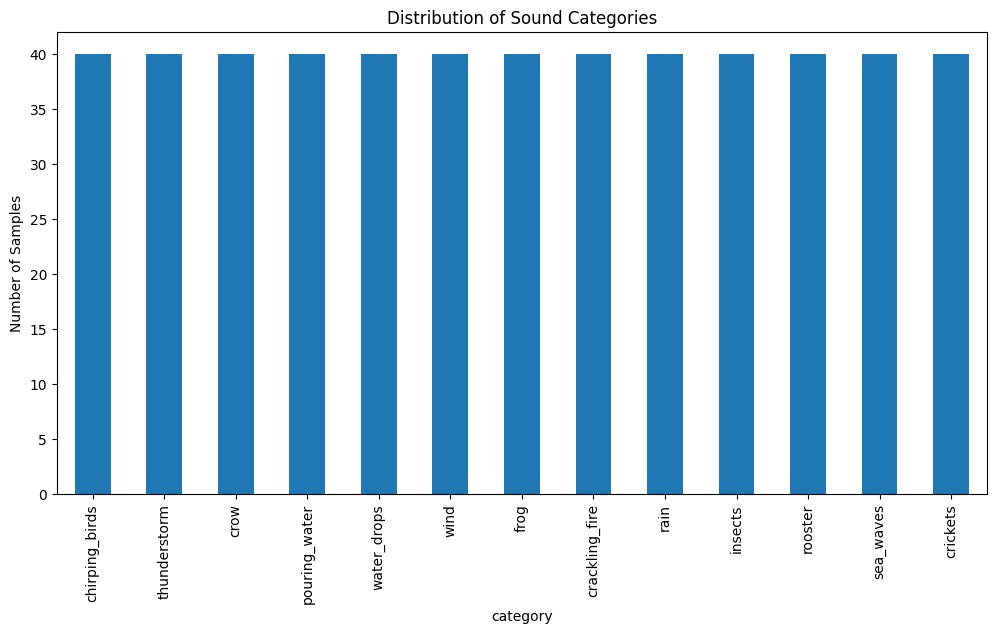

In [11]:
plt.figure(figsize=(12,6))

advanced_df["category"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Distribution of Sound Categories"
)

plt.ylabel("Number of Samples")

plt.show()

In [12]:
corr = advanced_df[
    feature_columns
].corr()

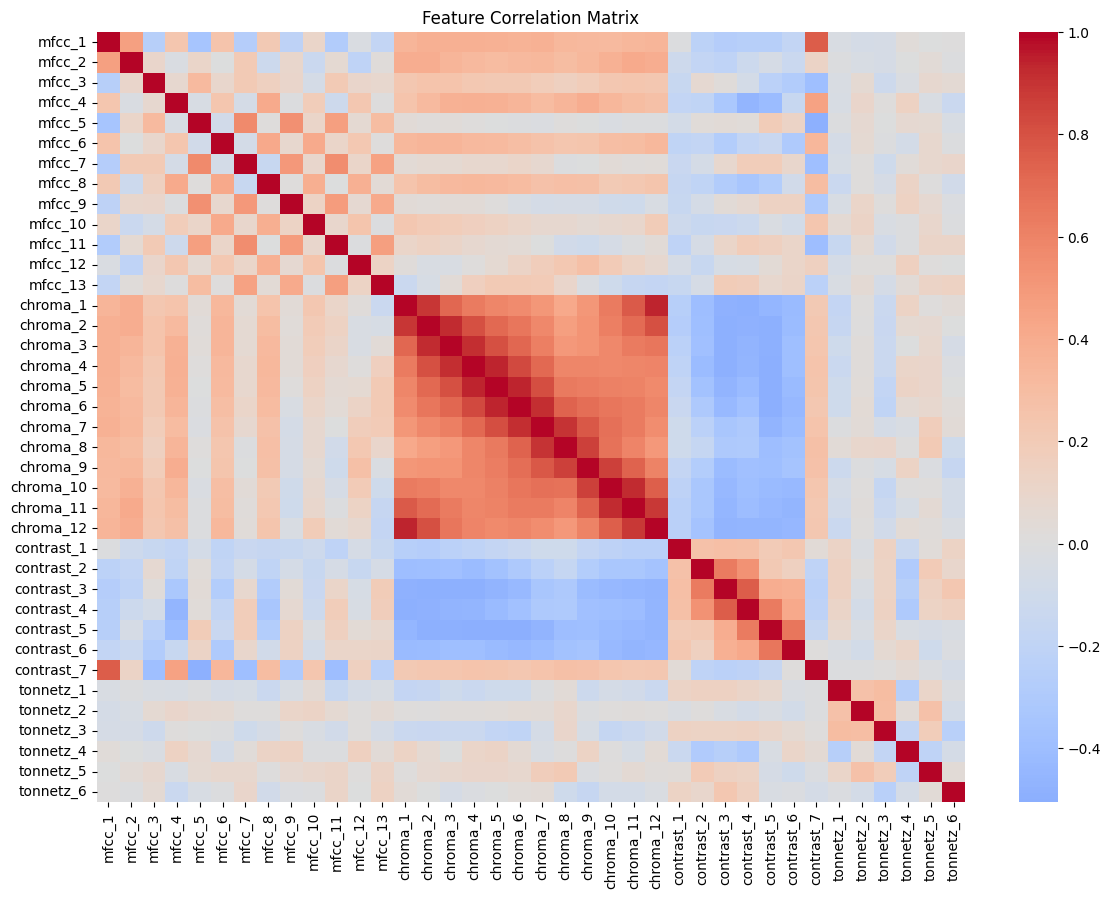

In [13]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Feature Correlation Matrix"
)

plt.show()

In [14]:
mfcc_columns = [
    col
    for col in feature_columns
    if "mfcc" in col
]

mfcc_columns

['mfcc_1',
 'mfcc_2',
 'mfcc_3',
 'mfcc_4',
 'mfcc_5',
 'mfcc_6',
 'mfcc_7',
 'mfcc_8',
 'mfcc_9',
 'mfcc_10',
 'mfcc_11',
 'mfcc_12',
 'mfcc_13']

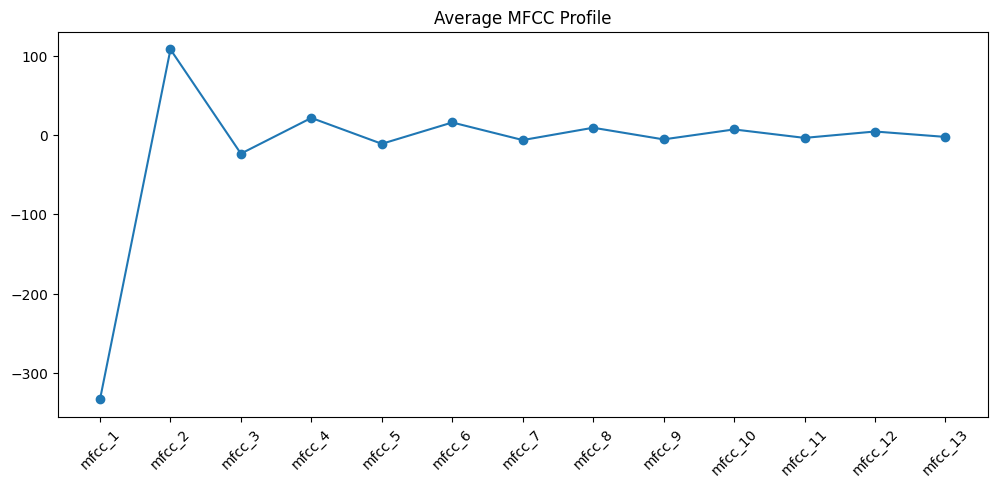

In [15]:
mfcc_means = advanced_df[
    mfcc_columns
].mean()

plt.figure(figsize=(12,5))

plt.plot(
    mfcc_means.index,
    mfcc_means.values,
    marker="o"
)

plt.title(
    "Average MFCC Profile"
)

plt.xticks(rotation=45)

plt.show()

In [16]:
chroma_columns = [
    col
    for col in feature_columns
    if "chroma" in col
]

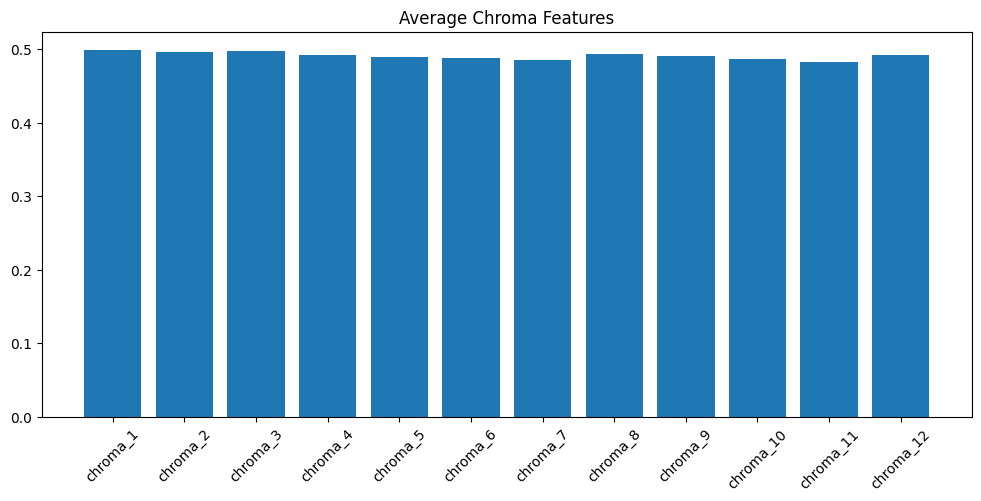

In [17]:
chroma_means = advanced_df[
    chroma_columns
].mean()

plt.figure(figsize=(12,5))

plt.bar(
    chroma_columns,
    chroma_means
)

plt.xticks(rotation=45)

plt.title(
    "Average Chroma Features"
)

plt.show()

In [18]:
results = pd.DataFrame({

    "Model":[
        "Random Forest",
        "SVM",
        "Gradient Boosting",
        "KNN"
    ],

    "Accuracy":[
        0.7212,
        0.6635,
        0.6058,
        0.5673
    ]
})

results

,Model,Accuracy
0,Random Forest,0.7212
1,SVM,0.6635
2,Gradient Boosting,0.6058
3,KNN,0.5673


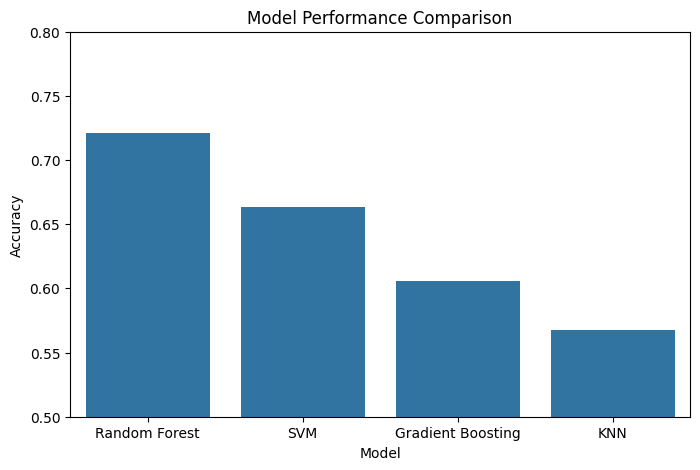

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title(
    "Model Performance Comparison"
)

plt.ylim(0.5,0.8)

plt.show()

In [20]:
print("BEST MODEL : Random Forest")
print("TEST ACCURACY :", "72.12%")
print("FULL DATASET ACCURACY :", "94.42%")
print("TOTAL CLASSES :", 13)
print("TOTAL SAMPLES :", 520)
print("TOTAL FEATURES :", 38)

BEST MODEL : Random Forest
TEST ACCURACY : 72.12%
FULL DATASET ACCURACY : 94.42%
TOTAL CLASSES : 13
TOTAL SAMPLES : 520
TOTAL FEATURES : 38
